# 01 · Análisis exploratorio

**Subconjunto:** categoría FOODS en la tienda CA_1 de M5 (Walmart).

El objetivo de este notebook no es describir el dataset sino **justificar las decisiones de
modelado**: cada variable que entra al modelo y cada supuesto de la política de inventario
debe poder señalar una figura de aquí.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src import config
from src.inventory import abc_xyz
from src.utils import plotting as pl

pl.use_style()
sales = pd.read_parquet(config.SALES_LONG)
classes = pd.read_parquet(config.ABC_XYZ)

## 1. Panorama

In [2]:
per_sku = sales.groupby("unique_id").agg(dias=("ds", "size"), unidades=("y", "sum"))
overview = pd.Series(
    {
        "Series (SKU-tienda)": f"{sales['unique_id'].nunique():,}",
        "Periodo": f"{sales['ds'].min().date()} → {sales['ds'].max().date()}",
        "Observaciones": f"{len(sales):,}",
        "Días con venta cero": f"{(sales['y'] == 0).mean():.1%}",
        "Mediana de unidades/día por SKU": f"{(per_sku['unidades'] / per_sku['dias']).median():.2f}",
        "SKUs con historia completa": f"{(per_sku['dias'] == per_sku['dias'].max()).mean():.1%}",
    },
    name="",
)
overview.to_frame()

,
Series (SKU-tienda),"1,429"
Periodo,2011-01-29 → 2016-05-22
Observaciones,"2,258,706"
Días con venta cero,46.8%
Mediana de unidades/día por SKU,1.13
SKUs con historia completa,43.9%


Casi la mitad de las observaciones son ceros y el SKU mediano vende alrededor de una unidad
al día. Esto ya adelanta dos decisiones: un objetivo de conteo (Tweedie) para el modelo, y
cautela con el supuesto de normalidad al calcular el safety stock. Más de la mitad de los
SKUs entró al surtido después del inicio del dataset: los días previos a su alta se
descartan (no son demanda cero, es que el producto no existía).

## 2. Demanda agregada: tendencia y estacionalidad anual

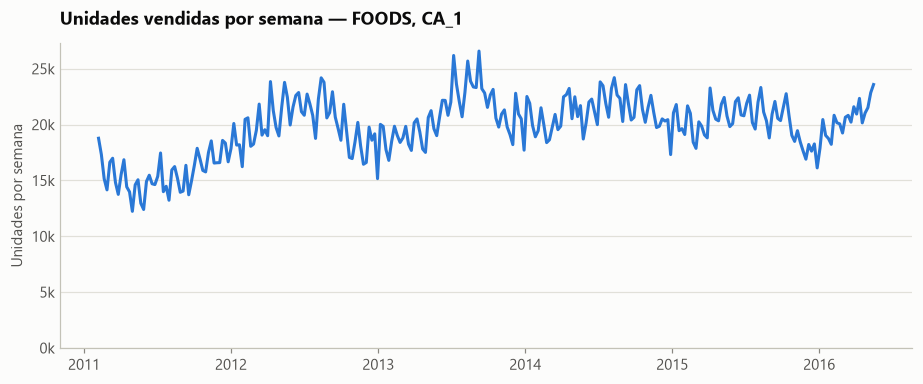

Días con la tienda cerrada: ['2011-12-25', '2012-12-25', '2013-12-25', '2014-12-25', '2015-12-25']


In [3]:
daily = sales.groupby("ds")["y"].sum()
weekly = daily.resample("W-SUN").sum().iloc[1:-1]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(weekly.index, weekly.to_numpy(), color=pl.BLUE)
ax.set_title("Unidades vendidas por semana — FOODS, CA_1")
ax.set_ylabel("Unidades por semana")
ax.set_ylim(0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")
pl.save(fig, "01_demanda_semanal")
plt.show()

closed = daily[daily < daily.median() * 0.05]
print("Días con la tienda cerrada:", [str(d.date()) for d in closed.index])

La demanda total crece y tiene un patrón anual suave. Los únicos días "anómalos" son las
Navidades (tienda cerrada): el modelo los aprende con la variable de evento.

## 3. Estacionalidad semanal

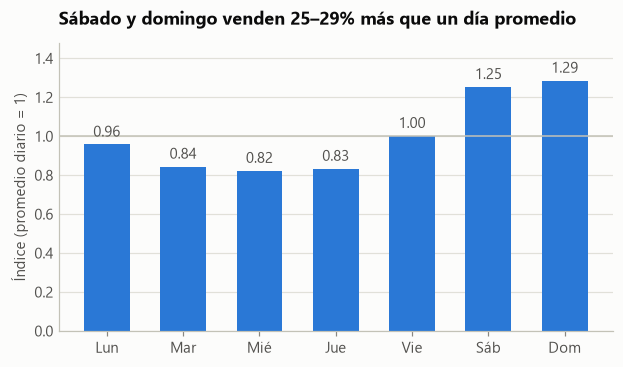

In [4]:
DAYS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
by_dow = daily.groupby(daily.index.dayofweek).mean()
index_dow = by_dow / by_dow.mean()

fig, ax = plt.subplots(figsize=(6.5, 3.4))
bars = ax.bar(DAYS, index_dow.to_numpy(), width=0.6, color=pl.BLUE)
ax.axhline(1, color=pl.AXIS, linewidth=1)
ax.bar_label(bars, labels=[f"{v:.2f}" for v in index_dow], padding=3, color=pl.INK_SECONDARY)
ax.set_title("Sábado y domingo venden 25–29% más que un día promedio")
ax.set_ylabel("Índice (promedio diario = 1)")
ax.set_ylim(0, index_dow.max() * 1.15)
pl.save(fig, "02_estacionalidad_semanal")
plt.show()

El ciclo semanal es el patrón más fuerte del dataset → `season_length = 7` en los baselines,
lags 7/14/28 y `dayofweek` en el modelo.

## 4. Efecto SNAP

SNAP es el programa federal de asistencia alimentaria; en California se deposita los
primeros 10 días del mes.

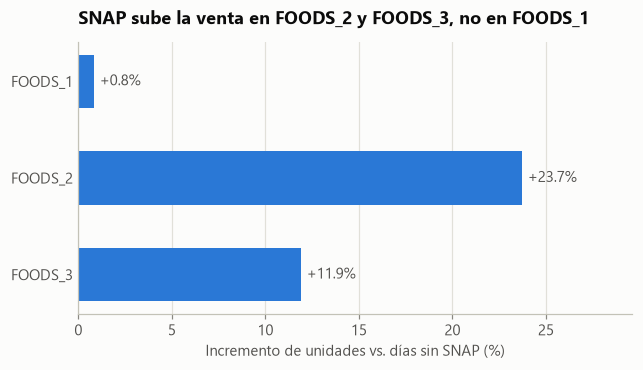

In [5]:
snap = sales.groupby(["dept_id", "ds", "snap"])["y"].sum().reset_index()
snap["dow"] = snap["ds"].dt.dayofweek
# Se compara dentro del mismo día de la semana para no confundir SNAP con el ciclo semanal.
cell = snap.groupby(["dept_id", "dow", "snap"])["y"].mean().unstack("snap")
lift = (cell[1] / cell[0] - 1).groupby("dept_id").mean()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.barh(lift.index[::-1], lift.to_numpy()[::-1] * 100, height=0.55, color=pl.BLUE)
ax.bar_label(bars, labels=[f"+{v:.1%}" for v in lift[::-1]], padding=4, color=pl.INK_SECONDARY)
ax.set_title("SNAP sube la venta en FOODS_2 y FOODS_3, no en FOODS_1")
ax.set_xlabel("Incremento de unidades vs. días sin SNAP (%)")
ax.set_xlim(0, lift.max() * 125)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
pl.save(fig, "03_efecto_snap")
plt.show()

El efecto no es uniforme: +24% en FOODS_2, +12% en FOODS_3 y prácticamente nulo en FOODS_1.
La variable `snap` entra al modelo junto con `dept_id` para que los árboles capturen esa
interacción.

## 5. Eventos: la compra ocurre *antes* del feriado

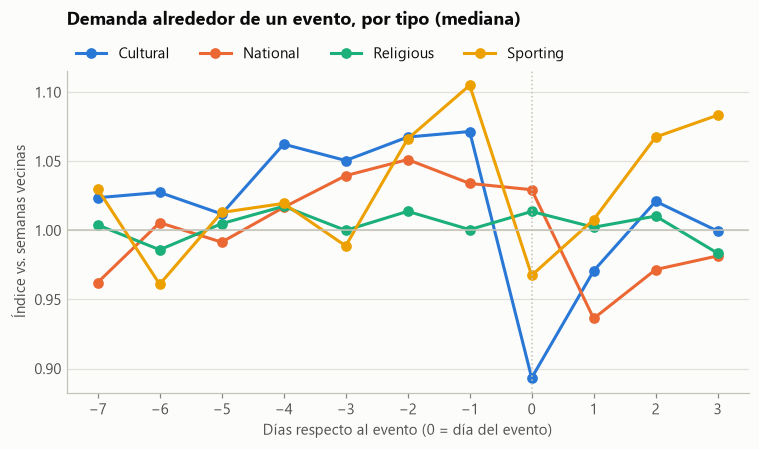

,-7,-6,-5,-4,-3,-2,-1,0,1,2,3
Cultural,1.02,1.03,1.01,1.06,1.05,1.07,1.07,0.89,0.97,1.02,1.00
National,0.96,1.01,0.99,1.02,1.04,1.05,1.03,1.03,0.94,0.97,0.98
Religious,1.00,0.99,1.00,1.02,1.00,1.01,1.00,1.01,1.00,1.01,0.98
Sporting,1.03,0.96,1.01,1.02,0.99,1.07,1.10,0.97,1.01,1.07,1.08


In [6]:
# Índice de cada día contra el mismo día de la semana en las 4 semanas previas y posteriores.
offsets = [k * 7 for k in (-4, -3, -2, -1, 1, 2, 3, 4)]
baseline = pd.concat([daily.shift(k) for k in offsets], axis=1).mean(axis=1)
index_day = daily / baseline

calendar = sales.drop_duplicates("ds").set_index("ds")
events = calendar.index[calendar["event_name_1"].notna()]
window = range(-7, 4)
profile = pd.DataFrame(
    {k: index_day.reindex(events + pd.Timedelta(days=k)).to_numpy() for k in window}, index=events
)
by_type = profile.groupby(calendar.loc[events, "event_type_1"].to_numpy()).median()

fig, ax = plt.subplots(figsize=(8, 3.8))
for (name, row), color in zip(by_type.iterrows(), pl.CATEGORICAL, strict=False):
    ax.plot(list(window), row.to_numpy(), marker="o", color=color, label=name)
ax.axhline(1, color=pl.AXIS, linewidth=1)
ax.axvline(0, color=pl.AXIS, linewidth=1, linestyle=":")
ax.set_title("Demanda alrededor de un evento, por tipo (mediana)", pad=30)
ax.set_xlabel("Días respecto al evento (0 = día del evento)")
ax.set_ylabel("Índice vs. semanas vecinas")
ax.set_xticks(list(window))
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=4, borderaxespad=0.2)
pl.save(fig, "04_efecto_eventos")
plt.show()

by_type.round(2)

El efecto es moderado (5–10%) y no se concentra en el día del evento: en los eventos
culturales y deportivos la venta sube los 2–4 días previos y en los culturales cae ~11% el
propio día; los religiosos no mueven la demanda de alimentos. Por eso el modelo recibe
`event_type`, `event_name` y **`days_to_event`** (cuenta regresiva de 7 días), no solo una
bandera del día.

## 6. Precio

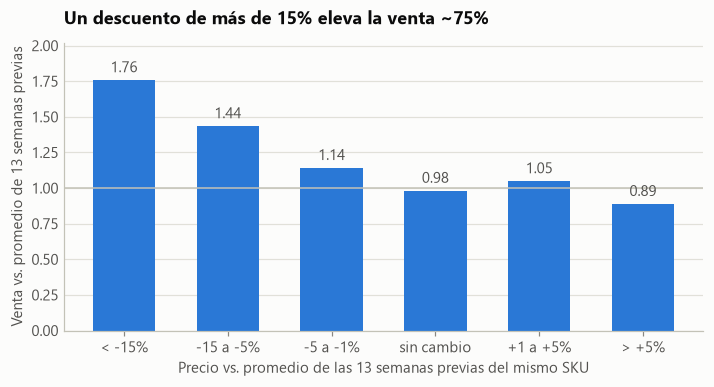

,indice,obs,participacion
bucket,,,
< -15%,1.757972,6103,0.3%
-15 a -5%,1.435145,36192,1.6%
-5 a -1%,1.141995,45301,2.0%
sin cambio,0.981855,1979818,89.2%
+1 a +5%,1.048841,92047,4.1%
> +5%,0.889336,59233,2.7%


In [7]:
# Precio y venta de cada día contra el promedio de las 13 semanas previas del mismo SKU
# (comparar contra la historia reciente evita confundir el precio con la tendencia).
price = sales[["unique_id", "ds", "y", "sell_price"]].copy()
by_sku = price.groupby("unique_id", sort=False)
price["price_ref"] = by_sku["sell_price"].transform(lambda s: s.shift(1).rolling(91, min_periods=28).mean())
price["y_ref"] = by_sku["y"].transform(lambda s: s.shift(1).rolling(91, min_periods=28).mean())
price = price.dropna(subset=["price_ref", "y_ref"]).copy()
price["rel"] = price["sell_price"] / price["price_ref"]

bins = [0, 0.85, 0.95, 0.99, 1.01, 1.05, np.inf]
labels = ["< -15%", "-15 a -5%", "-5 a -1%", "sin cambio", "+1 a +5%", "> +5%"]
price["bucket"] = pd.cut(price["rel"], bins=bins, labels=labels)
resp = price.groupby("bucket", observed=True).agg(y=("y", "sum"), y_ref=("y_ref", "sum"), obs=("y", "size"))
resp["indice"] = resp["y"] / resp["y_ref"]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(resp.index.astype(str), resp["indice"].to_numpy(), width=0.6, color=pl.BLUE)
ax.axhline(1, color=pl.AXIS, linewidth=1)
ax.bar_label(bars, labels=[f"{v:.2f}" for v in resp["indice"]], padding=3, color=pl.INK_SECONDARY)
ax.set_title("Un descuento de más de 15% eleva la venta ~75%")
ax.set_xlabel("Precio vs. promedio de las 13 semanas previas del mismo SKU")
ax.set_ylabel("Venta vs. promedio de 13 semanas previas")
ax.set_ylim(0, resp["indice"].max() * 1.15)
pl.save(fig, "05_efecto_precio")
plt.show()

resp[["indice", "obs"]].assign(participacion=lambda d: (d["obs"] / d["obs"].sum()).map("{:.1%}".format))

El nivel absoluto del precio dice poco (cada SKU tiene el suyo); lo informativo es el
precio **relativo** a la historia reciente del propio SKU → `price_rel_item` y
`price_change_7`. La respuesta es monótona: de +14% con descuentos pequeños a +76% con
descuentos mayores a 15%, y −11% cuando el precio sube más de 5%. Pero el 89% de los días
no hay cambio de precio: el efecto es fuerte y poco frecuente.

## 7. Intermitencia: qué tipo de demanda tenemos

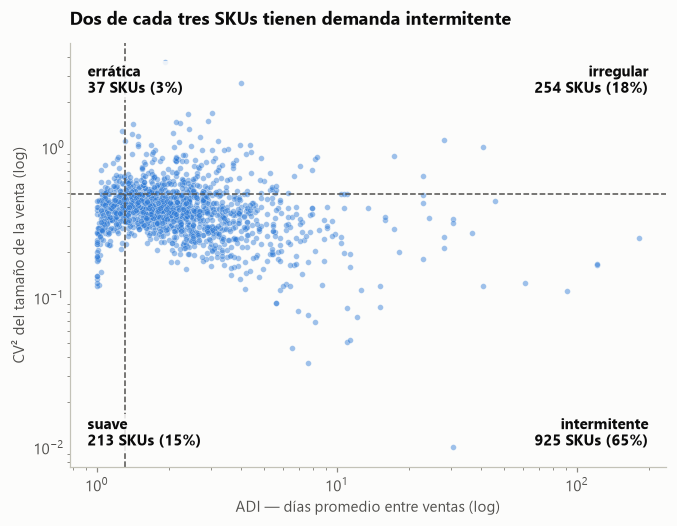

In [8]:
tab = classes.copy()
finite = tab[np.isfinite(tab["adi"])]
counts = tab["pattern"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(finite["adi"], finite["cv2"].clip(lower=0.01), s=14, color=pl.BLUE, alpha=0.45,
           edgecolors=pl.SURFACE, linewidths=0.3)
ax.axvline(abc_xyz.ADI_CUT, color=pl.INK_SECONDARY, linewidth=1, linestyle="--")
ax.axhline(abc_xyz.CV2_CUT, color=pl.INK_SECONDARY, linewidth=1, linestyle="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(visible=False)
corners = {"suave": (0.03, 0.04), "errática": (0.03, 0.95), "intermitente": (0.97, 0.04),
           "irregular": (0.97, 0.95)}
for name, (x, y) in corners.items():
    n = counts.get(name, 0)
    ax.text(x, y, f"{name}\n{n} SKUs ({n / len(tab):.0%})", transform=ax.transAxes,
            ha="left" if x < 0.5 else "right", va="bottom" if y < 0.5 else "top",
            fontsize=10, fontweight="bold", color=pl.INK,
            bbox={"facecolor": pl.SURFACE, "edgecolor": "none", "alpha": 0.85, "pad": 2})
ax.set_title("Dos de cada tres SKUs tienen demanda intermitente")
ax.set_xlabel("ADI — días promedio entre ventas (log)")
ax.set_ylabel("CV² del tamaño de la venta (log)")
pl.save(fig, "06_patron_demanda")
plt.show()

Clasificación de Syntetos-Boylan (cortes ADI = 1.32 y CV² = 0.49), calculada con los 365
días previos al periodo de evaluación. Solo ~15% de los SKUs tiene demanda "suave", que es
el caso para el que está pensada la fórmula clásica `z·σ·√L`. Implicaciones:

- **Modelo global:** un SKU que vende una unidad cada varios días no tiene señal propia
  suficiente; aprende de los demás.
- **Inventario:** se comparará el safety stock normal contra uno basado en cuantiles
  empíricos del error.

## 8. Priorización ABC / XYZ

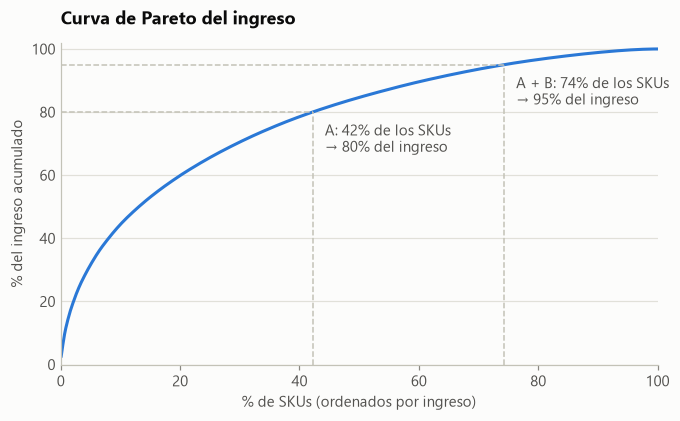

In [9]:
order = tab.sort_values("revenue", ascending=False).reset_index(drop=True)
cum = order["revenue"].cumsum() / order["revenue"].sum()
share_skus = (order.index + 1) / len(order)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(share_skus * 100, cum * 100, color=pl.BLUE)
for cls, cut in zip(("A", "A + B"), abc_xyz.ABC_CUTS, strict=True):
    x = share_skus[(cum >= cut).argmax()] * 100
    ax.plot([x, x], [0, cut * 100], color=pl.AXIS, linewidth=1, linestyle="--")
    ax.plot([0, x], [cut * 100, cut * 100], color=pl.AXIS, linewidth=1, linestyle="--")
    ax.annotate(f"{cls}: {x:.0f}% de los SKUs\n→ {cut:.0%} del ingreso",
                (x, cut * 100), xytext=(8, -26), textcoords="offset points", color=pl.INK_SECONDARY)
ax.set_title("Curva de Pareto del ingreso")
ax.set_xlabel("% de SKUs (ordenados por ingreso)")
ax.set_ylabel("% del ingreso acumulado")
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
pl.save(fig, "07_pareto_abc")
plt.show()

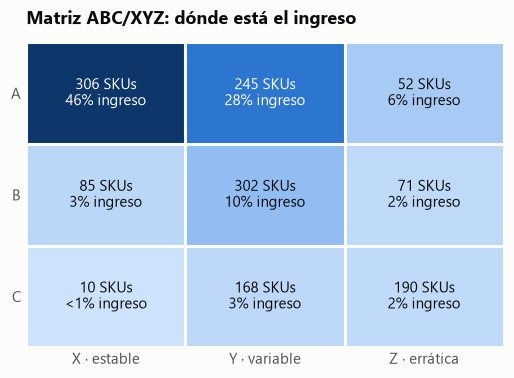

In [10]:
matrix = pd.crosstab(tab["abc"], tab["xyz"])
rev = tab.pivot_table(index="abc", columns="xyz", values="revenue_share", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
cmap = LinearSegmentedColormap.from_list("blue", pl.SEQUENTIAL)
im = ax.imshow(rev.to_numpy(), cmap=cmap, vmin=0, aspect="auto")
for i in range(3):
    for j in range(3):
        dark = rev.iloc[i, j] > rev.to_numpy().max() * 0.5
        share = f"{rev.iloc[i, j]:.0%}" if rev.iloc[i, j] >= 0.005 else "<1%"
        ax.text(j, i, f"{matrix.iloc[i, j]} SKUs\n{share} ingreso", ha="center",
                va="center", color="white" if dark else pl.INK, fontsize=9.5)
ax.set_xticks(range(3), ["X · estable", "Y · variable", "Z · errática"])
ax.set_yticks(range(3), ["A", "B", "C"])
ax.set_xticks(np.arange(-0.5, 3), minor=True)
ax.set_yticks(np.arange(-0.5, 3), minor=True)
ax.grid(visible=False)
ax.grid(which="minor", color=pl.SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
for side in ("left", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title("Matriz ABC/XYZ: dónde está el ingreso")
pl.save(fig, "08_matriz_abc_xyz")
plt.show()

- **ABC** por ingreso (A = 80%, B = 15%, C = 5%); **XYZ** por coeficiente de variación de la
  demanda *semanal* (X ≤ 0.5, Y ≤ 1.0, Z > 1.0).
- Los segmentos **AX y AY** concentran la mayor parte del ingreso: ahí un mejor pronóstico se
  traduce directamente en menos inventario. En **CZ** casi cualquier método es ruido: la
  pregunta relevante es si conviene tener el producto, no cómo pronosticarlo.
- La meta de servicio del proyecto (fill rate ≥ 95%) se evalúa sobre la clase A.

## Resumen: del EDA a las decisiones

| Hallazgo | Decisión |
| --- | --- |
| 47% de ceros; SKU mediano ≈ 1 unidad/día | Objetivo Tweedie; modelo global en vez de uno por serie |
| Ciclo semanal dominante | `season_length=7`, lags 7/14/28, `dayofweek` |
| SNAP: +24% en FOODS_2, +12% en FOODS_3, nulo en FOODS_1 | Variable `snap` junto con `dept_id` |
| Eventos: efecto de 5–10% en los días previos, según el tipo | `event_type`, `event_name`, `days_to_event` |
| Descuentos de +15% elevan la venta ~75%; 89% de los días sin cambio | `price_rel_item`, `price_rel_dept`, `price_change_7` |
| ~65% de SKUs intermitentes | Comparar safety stock normal vs. cuantil empírico del error |
| A = 42% de los SKUs y 80% del ingreso | Métricas y meta de servicio reportadas por clase ABC |